# Project Title
## Uber Trip Demand Analysis and Forecasting using Machine Learning

### Step 1 — Data Collection & Environment Setup
#### Objective: To prepare the analysis environment and load all Uber trip datasets required for the project.
Purpose : The goal of this step is to ensure that all required datasets are accessible in the Jupyter Notebook environment and that necessary libraries for data analysis, visualization, and machine learning are properly imported.
This step also verifies that the dataset files are correctly recognized before performing any preprocessing or analysis.

In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Set dataset directory path

data_path = "."

In [3]:
# Display all dataset files

files = os.listdir(data_path)
files

['.ipynb_checkpoints',
 'other-American_B01362.csv',
 'other-Carmel_B00256.csv',
 'other-Dial7_B00887.csv',
 'other-Diplo_B01196.csv',
 'other-Federal_02216.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Highclass_B01717.csv',
 'other-Lyft_B02510.csv',
 'other-Prestige_B01338.csv',
 'other-Skyline_B00111.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-janjune-15.csv',
 'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv',
 'uber_trip_analysis.ipynb']

### Step 2 — Data Loading and Dataset Integration

#### Objective : To load all Uber trip datasets into the Jupyter Notebook and combine the 2014 monthly trip files into a single unified dataset for analysis.

Purpose : The Uber dataset is divided into multiple CSV files by month. For proper analysis, these files must be loaded and merged into a single dataset so that the complete trip data can be analyzed collectively.
This step ensures that all trip records are successfully imported and structured for further preprocessing and exploration.

In [4]:
# Identify Uber 2014 monthly files

uber_2014_files = [
    "uber-raw-data-apr14.csv",
    "uber-raw-data-may14.csv",
    "uber-raw-data-jun14.csv",
    "uber-raw-data-jul14.csv",
    "uber-raw-data-aug14.csv",
    "uber-raw-data-sep14.csv"
]

In [5]:
# Load all datasets into a list of DataFrames

dataframes = []

for file in uber_2014_files:
    df = pd.read_csv(os.path.join(data_path, file))
    dataframes.append(df)

In [6]:
# Merge all monthly datasets into one dataset

uber_2014_data = pd.concat(dataframes, ignore_index=True)

In [7]:
# Check dataset size

uber_2014_data.shape

(4534327, 4)

In [8]:
# Display first 5 rows of dataset

uber_2014_data.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [9]:
uber_2014_data.tail()

,Date/Time,Lat,Lon,Base
4534322,9/30/2014 22:57:00,40.7668,-73.9845,B02764
4534323,9/30/2014 22:57:00,40.6911,-74.1773,B02764
4534324,9/30/2014 22:58:00,40.8519,-73.9319,B02764
4534325,9/30/2014 22:58:00,40.7081,-74.0066,B02764
4534326,9/30/2014 22:58:00,40.7140,-73.9496,B02764


In [10]:
# Display dataset structure

uber_2014_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  object 
 1   Lat        float64
 2   Lon        float64
 3   Base       object 
dtypes: float64(2), object(2)
memory usage: 138.4+ MB


### Step 3 — Data Understanding (Dataset Exploration)

#### Objective : To understand the structure, quality, and statistical characteristics of the Uber trip dataset before performing data cleaning and feature engineering.

Purpose :
Before analyzing or modeling the data, it is important to inspect the dataset to understand:
1.data types
2.missing values
3.duplicate records
4.statistical distribution
5.unique values in categorical columns
This step helps identify potential issues and ensures that the dataset is suitable for further analysis.

In [11]:
uber_2014_data.info()

uber_2014_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  object 
 1   Lat        float64
 2   Lon        float64
 3   Base       object 
dtypes: float64(2), object(2)
memory usage: 138.4+ MB


Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='object')

In [12]:
# Generate statistical summary

uber_2014_data.describe()

,Lat,Lon
count,4.534327e+06,4.534327e+06
mean,4.073926e+01,-7.397302e+01
std,3.994991e-02,5.726670e-02
min,3.965690e+01,-7.492900e+01
25%,4.072110e+01,-7.399650e+01
50%,4.074220e+01,-7.398340e+01
75%,4.076100e+01,-7.396530e+01
max,4.211660e+01,-7.206660e+01


In [13]:
uber_2014_data.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

In [14]:
uber_2014_data.duplicated().sum()

np.int64(82581)

In [15]:
uber_2014_data["Base"].unique()

array(['B02512', 'B02598', 'B02617', 'B02682', 'B02764'], dtype=object)

In [16]:
# Count trips handled by each Uber base

uber_2014_data["Base"].value_counts()

Base
B02617    1458853
B02598    1393113
B02682    1212789
B02764     263899
B02512     205673
Name: count, dtype: int64

### Step 4 — Data Cleaning & Data Preparation

#### Objective : To clean and transform the Uber trip dataset so that it becomes structured and ready for analysis and machine learning.

Purpose : Raw datasets often contain columns that are not in the correct format for analysis. In this dataset:
1.Date/Time is stored as text instead of a datetime format.
2.Time-related insights such as hourly demand or weekday demand cannot be analyzed directly.
Therefore, we convert the date column into a proper datetime format and extract useful time features that will help in exploratory analysis and demand forecasting.

In [17]:
uber_2014_data["Date/Time"] = pd.to_datetime(uber_2014_data["Date/Time"])

In [18]:
uber_2014_data["Hour"] = uber_2014_data["Date/Time"].dt.hour

In [19]:
uber_2014_data["minute"] = uber_2014_data["Date/Time"].dt.minute

In [20]:
uber_2014_data["Day"] = uber_2014_data["Date/Time"].dt.day

In [21]:
uber_2014_data["DayOfWeek"] = uber_2014_data["Date/Time"].dt.dayofweek

In [22]:
uber_2014_data["Month"] = uber_2014_data["Date/Time"].dt.month

In [23]:
uber_2014_data.head()

,Date/Time,Lat,Lon,Base,Hour,minute,Day,DayOfWeek,Month
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,11,1,1,4
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,17,1,1,4
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,21,1,1,4
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,28,1,1,4
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,33,1,1,4


In [24]:
uber_2014_data.tail()

,Date/Time,Lat,Lon,Base,Hour,minute,Day,DayOfWeek,Month
4534322,2014-09-30 22:57:00,40.7668,-73.9845,B02764,22,57,30,1,9
4534323,2014-09-30 22:57:00,40.6911,-74.1773,B02764,22,57,30,1,9
4534324,2014-09-30 22:58:00,40.8519,-73.9319,B02764,22,58,30,1,9
4534325,2014-09-30 22:58:00,40.7081,-74.0066,B02764,22,58,30,1,9
4534326,2014-09-30 22:58:00,40.7140,-73.9496,B02764,22,58,30,1,9


### Step 5 — Exploratory Data Analysis (EDA)

#### Objective : To analyze Uber trip patterns across time and identify key demand trends such as peak hours, busiest weekdays, and monthly trip distribution.

Purpose : 
Exploratory Data Analysis helps transform raw data into meaningful insights by visualizing patterns and trends.
Through this step we aim to answer questions such as:
1.When do most Uber trips occur during the day?
2.Which days of the week have the highest demand?
3.How does Uber demand change across months?
4.Which Uber base handles the most trips?
Understanding these patterns helps reveal customer behavior and operational demand trends.

#### 1.Uber Trips by Hour of the Day

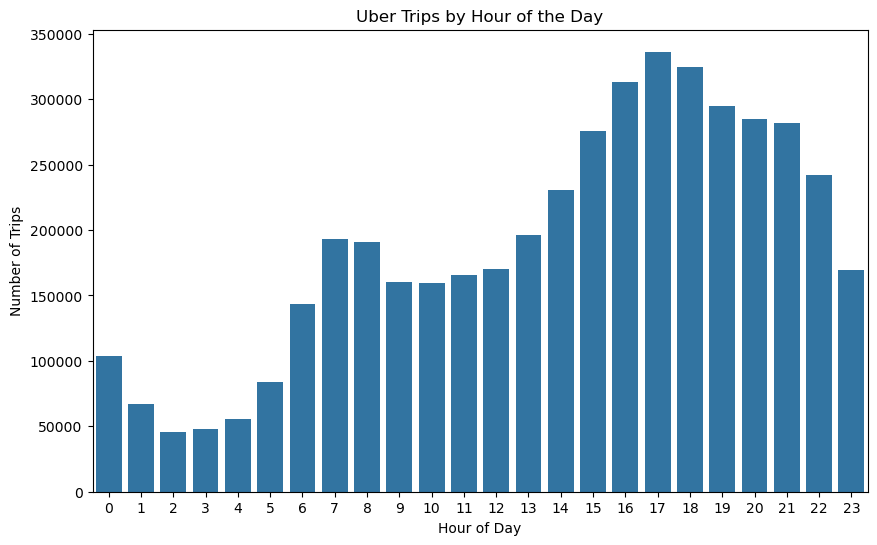

In [25]:
# Plot number of trips per hour

plt.figure(figsize=(10,6))

sns.countplot(x="Hour", data=uber_2014_data)

plt.title("Uber Trips by Hour of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.show()

Observation:-
Uber trip demand varies significantly throughout the day. Trip activity is lowest during early morning hours (2 AM – 5 AM) and begins increasing after 6 AM as people start commuting.
Demand continues to grow during the afternoon and reaches its peak between 5 PM and 6 PM, which corresponds to evening rush hours when people return from work or social activities.

Key Insight:-
The chart clearly shows that evening hours are the busiest period for Uber services, indicating strong demand during post-work travel times.

#### 2.Uber Trips by Day of Week

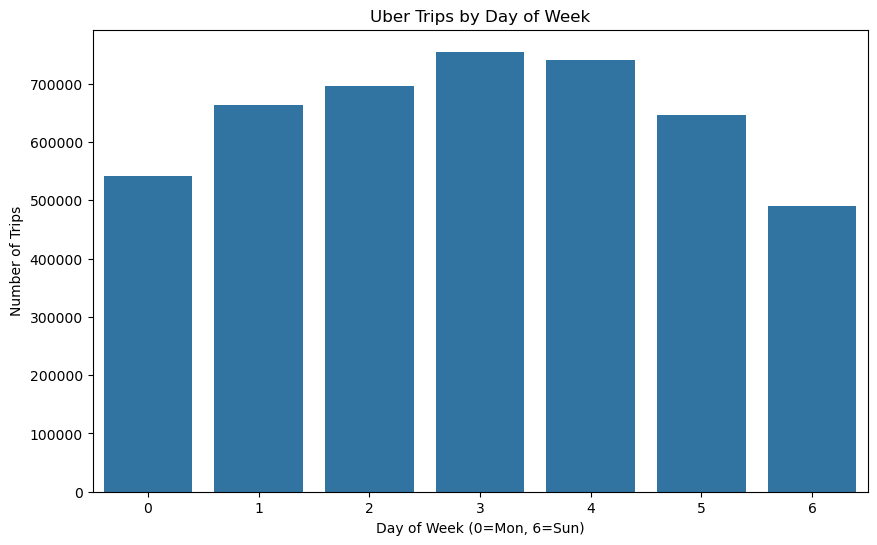

In [26]:
# Plot trips by weekday

plt.figure(figsize=(10,6))

sns.countplot(x="DayOfWeek", data=uber_2014_data)

plt.title("Uber Trips by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Number of Trips")

plt.show()

Observation:-
Trip demand gradually increases from Monday to Thursday, with the highest number of trips recorded on Wednesday and Thursday.
Demand slightly decreases on Friday and Saturday, and reaches its lowest point on Sunday.

Key Insight:-
Uber usage is highest during midweek working days, indicating that the platform is heavily used for daily commuting and work-related travel.

#### 3.Uber Trips by Month

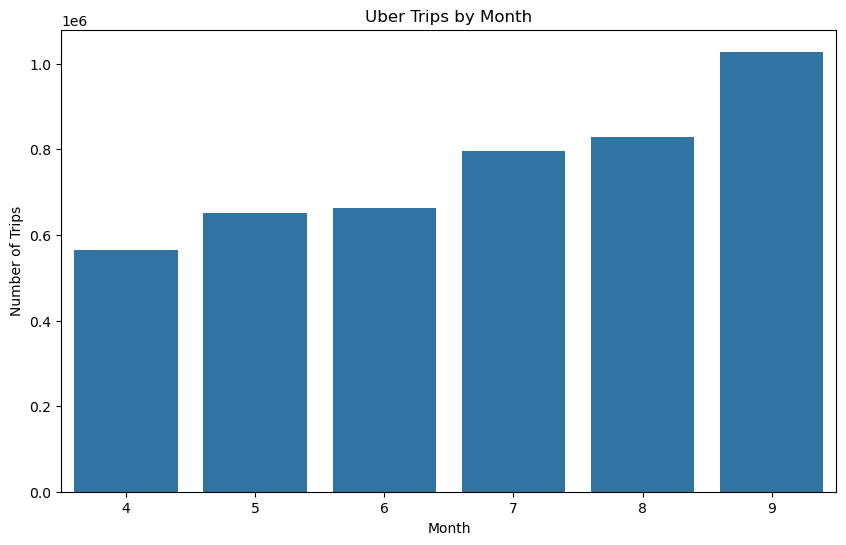

In [27]:
# Plot trips per month

plt.figure(figsize=(10,6))

sns.countplot(x="Month", data=uber_2014_data)

plt.title("Uber Trips by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")

plt.show()

Observation:-
The number of Uber trips shows a consistent upward trend from April to September.
Trip volume increases steadily each month, with September recording the highest number of trips in the dataset.

Key Insight:-
This trend suggests that Uber adoption and usage were rapidly increasing during 2014, reflecting growth in ride-sharing popularity in New York City.

#### 4.Trips by Uber Base

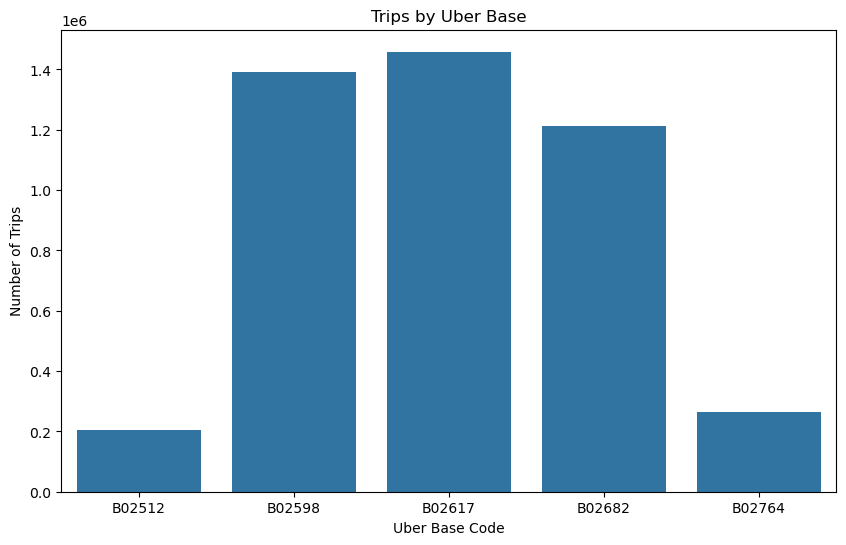

In [28]:
# Plot trips handled by each Uber base

plt.figure(figsize=(10,6))

sns.countplot(x="Base", data=uber_2014_data)

plt.title("Trips by Uber Base")
plt.xlabel("Uber Base Code")
plt.ylabel("Number of Trips")

plt.show()

Observation:-
Trip distribution across Uber bases shows significant variation. Bases B02617, B02598, and B02682 handle the majority of trips, while B02512 and B02764 manage comparatively fewer trips.
Among them, B02617 processes the highest number of trips, indicating it is one of the primary operational hubs.

Key Insight:-
Uber operations appear to be concentrated in a few major dispatch bases, which likely manage higher demand regions within the city.

#### 5.Uber Demand Heatmap (Hour vs Day)

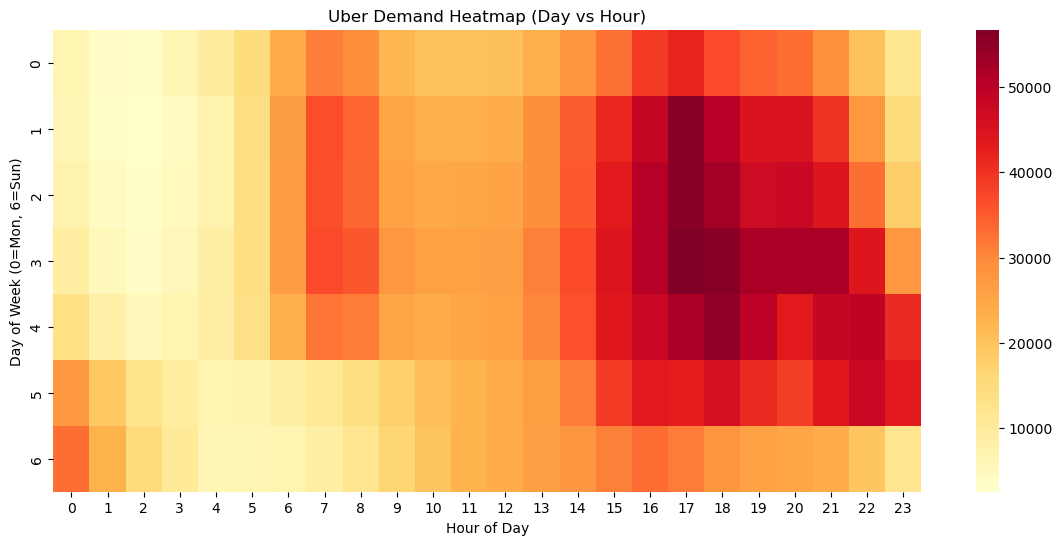

In [29]:
# Create pivot table for heatmap

heatmap_data = uber_2014_data.pivot_table(
    index="DayOfWeek",
    columns="Hour",
    values="Base",
    aggfunc="count"
)

# Plot heatmap

plt.figure(figsize=(14,6))

sns.heatmap(heatmap_data, cmap="YlOrRd")

plt.title("Uber Demand Heatmap (Day vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Mon, 6=Sun)")

plt.show()

#### Insight : 
The heatmap highlights strong demand during evening hours (5 PM – 8 PM) across most weekdays, indicating typical commuting behavior. Weekend nights also show increased ride activity due to leisure and social travel.

#### 6.Geographic Location Analysis 

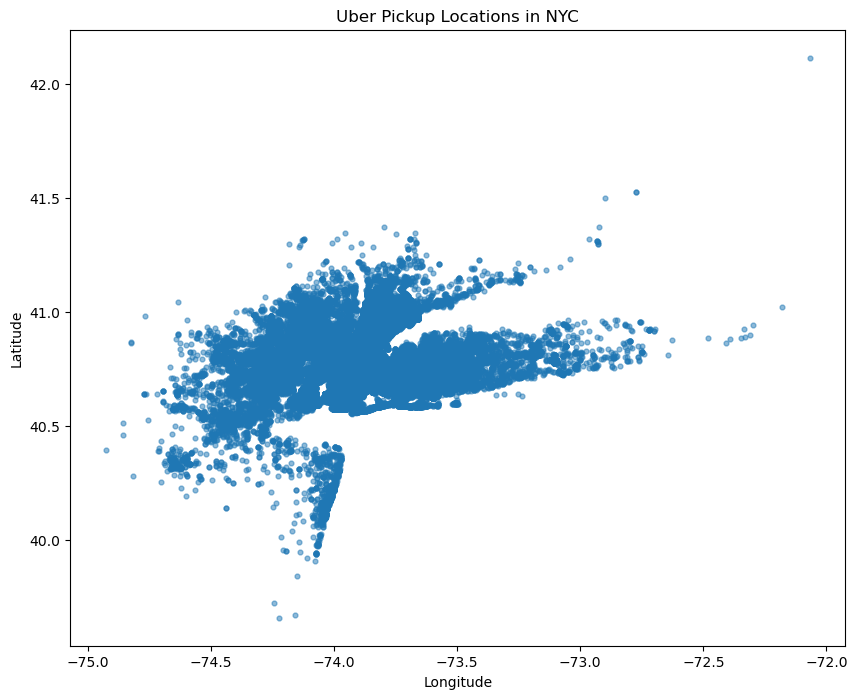

In [30]:
# Uber Trip Location Scatter Map

plt.figure(figsize=(10,8))

plt.scatter(
    uber_2014_data["Lon"],
    uber_2014_data["Lat"],
    s=12,
    alpha=0.5
    )

plt.title("Uber Pickup Locations in NYC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

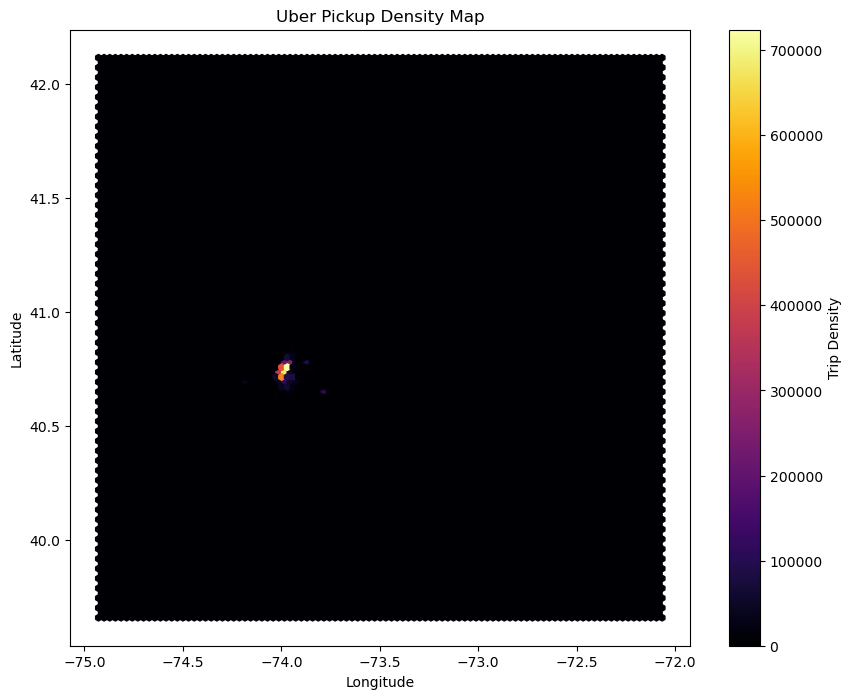

In [31]:
#Advanced Geographic Density Map (Hexbin)
plt.figure(figsize=(10,8))

plt.hexbin(
    uber_2014_data["Lon"],
    uber_2014_data["Lat"],
    gridsize=100,
    cmap="inferno"
)

plt.colorbar(label="Trip Density")

plt.title("Uber Pickup Density Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

#### Insight
The scatter plot shows dense clusters of Uber pickups concentrated in central urban areas of New York City, indicating high demand in commercial and residential zones.

Scatter Plot : Trips concentrated in urban core

Hexbin Map : High pickup density 

KDE Density	: Major demand hotspots identified

#### 7.Load Competitor Datasets

In [32]:
#Load Competitor Datasets
import os
import pandas as pd

fhv_files = [
    "other-Lyft_B02510.csv",
    "other-American_B01362.csv",
    "other-Carmel_B00256.csv"
]

fhv_counts = {}

for file in fhv_files:
    
    file_path = os.path.join(data_path, file)
    
    df = pd.read_csv(file_path, encoding='latin1')
    
    company = file.split("_")[1].split(".")[0]
    
    fhv_counts[company] = len(df)

fhv_counts

{'B02510': 267701, 'B01362': 91712, 'B00256': 256519}

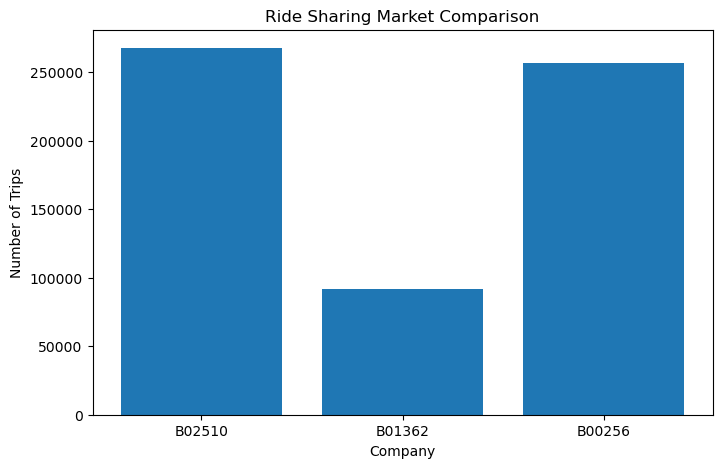

In [33]:
plt.figure(figsize=(8,5))

plt.bar(
    fhv_counts.keys(),
    fhv_counts.values()
)

plt.title("Ride Sharing Market Comparison")
plt.xlabel("Company")
plt.ylabel("Number of Trips")

plt.show()

#### Insight : 

The comparison reveals that:
Uber operates at significantly larger scale than most competitors.
The ride-sharing market shows strong competition but Uber dominates trip volume.

#### 8.Ride-Sharing Market Share Analysis

In [34]:
import os
import pandas as pd

fhv_files = [
    "other-Lyft_B02510.csv",
    "other-American_B01362.csv",
    "other-Carmel_B00256.csv",
    "other-Dial7_B00887.csv",
    "other-Diplo_B01196.csv"
]

fhv_counts = {}

for file in fhv_files:
    
    file_path = os.path.join(data_path, file)
    
    try:
        df = pd.read_csv(file_path)
    except:
        df = pd.read_csv(file_path, encoding="latin1")
    
    company = file.split("_")[1].split(".")[0]
    
    fhv_counts[company] = len(df)

fhv_counts

{'B02510': 267701,
 'B01362': 91712,
 'B00256': 256519,
 'B00887': 194992,
 'B01196': 98550}

In [35]:
fhv_df = pd.DataFrame(
    list(fhv_counts.items()),
    columns=["Company", "Trips"]
)

fhv_df

,Company,Trips
0,B02510,267701
1,B01362,91712
2,B00256,256519
3,B00887,194992
4,B01196,98550


In [36]:
fhv_df["MarketShare_%"] = (
    fhv_df["Trips"] / fhv_df["Trips"].sum()
) * 100

fhv_df

,Company,Trips,MarketShare_%
0,B02510,267701,29.434706
1,B01362,91712,10.084071
2,B00256,256519,28.205204
3,B00887,194992,21.440085
4,B01196,98550,10.835934


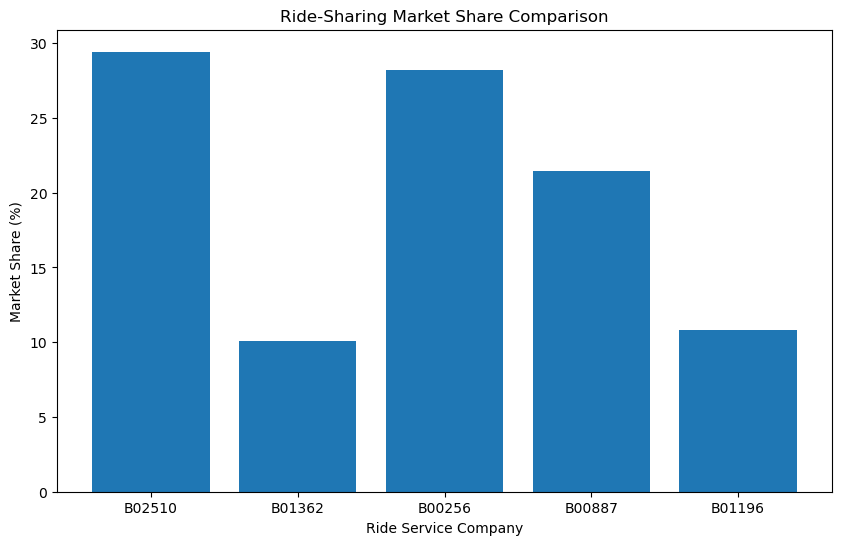

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    fhv_df["Company"],
    fhv_df["MarketShare_%"]
)

plt.title("Ride-Sharing Market Share Comparison")
plt.xlabel("Ride Service Company")
plt.ylabel("Market Share (%)")

plt.show()

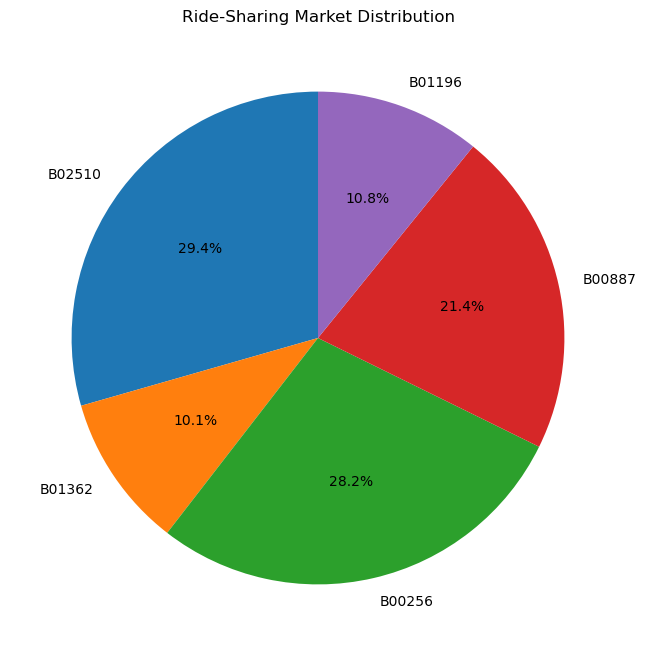

In [38]:
plt.figure(figsize=(8,8))

plt.pie(
    fhv_df["MarketShare_%"],
    labels=fhv_df["Company"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Ride-Sharing Market Distribution")

plt.show()

### Professional EDA Summary:

The exploratory analysis reveals clear temporal and spatial patterns in Uber demand. Evening hours consistently show the highest trip activity, while weekday demand remains stronger compared to weekends. Geographic analysis indicates dense pickup activity in central urban areas of New York City. Additionally, the time-series trend highlights recurring daily demand cycles, confirming the suitability of the dataset for time-series forecasting models.

The market share analysis reveals that ride demand is distributed across multiple companies, with certain operators controlling a larger portion of trips. This comparison highlights the competitive dynamics of the ride-sharing ecosystem and provides context for Uber’s operational scale within the broader FHV market.

### Step 6 — Time Series Data Preparation

#### Objective : To transform the Uber trip dataset into a time-series format representing hourly trip demand, which will be used for forecasting and machine learning models.

#### Purpose

Currently, the dataset contains individual trip records, where each row represents a single Uber pickup.
However, forecasting models require a time-series dataset, where each row represents the number of trips occurring within a specific time interval.

Therefore, we aggregate the data into hourly trip counts, converting raw trip events into a structured demand dataset.

This step prepares the dataset for predictive modeling and demand forecasting.

In [42]:
# Convert Date/Time column to datetime format

uber_2014_data["Date/Time"] = pd.to_datetime(uber_2014_data["Date/Time"])

In [43]:
# Sort dataset chronologically

uber_2014_data = uber_2014_data.sort_values("Date/Time")

In [44]:
# Set Date/Time as index

uber_2014_data.set_index("Date/Time", inplace=True)

In [45]:
# Aggregate trips per hour

uber_hourly_trips = uber_2014_data.resample("H").size()

C:\Users\Admin\AppData\Local\Temp\ipykernel_12464\2132355123.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  uber_hourly_trips = uber_2014_data.resample("H").size()


In [46]:
# Convert to DataFrame

uber_hourly_trips = uber_hourly_trips.to_frame(name="Trips")

In [47]:
uber_hourly_trips.head()

,Trips
Date/Time,
2014-04-01 00:00:00,138
2014-04-01 01:00:00,66
2014-04-01 02:00:00,53
2014-04-01 03:00:00,93
2014-04-01 04:00:00,166


In [48]:
uber_hourly_trips.shape

(4391, 1)

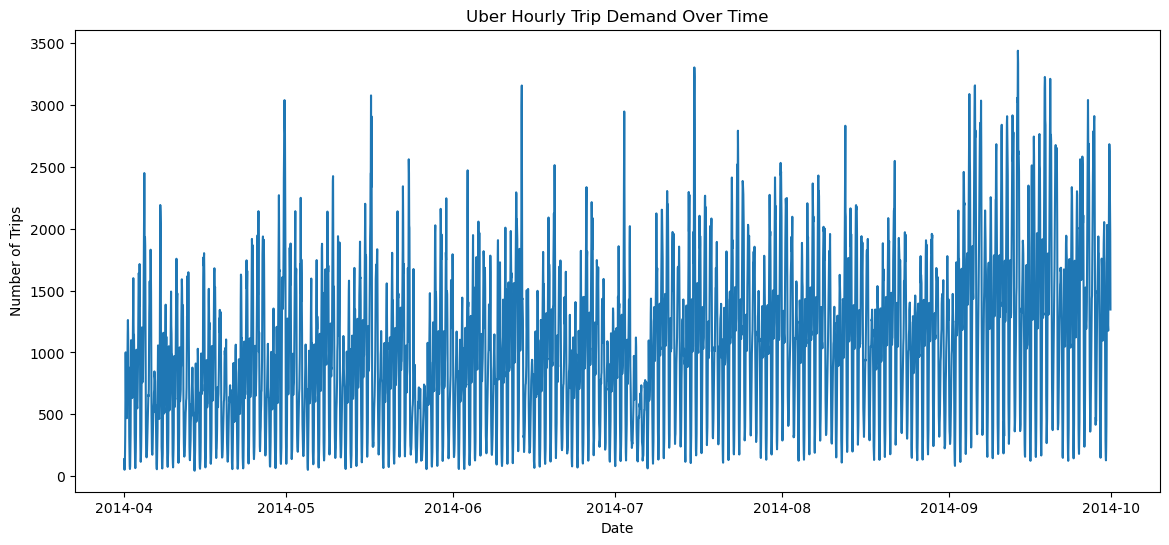

In [49]:
plt.figure(figsize=(14,6))

plt.plot(uber_hourly_trips["Trips"])

plt.title("Uber Hourly Trip Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Trips")

plt.show()

#### Insight

The time-series plot shows clear patterns:

recurring daily cycles

strong rush-hour demand peaks

gradual growth in ride demand

These patterns indicate that the dataset is well suited for demand forecasting models

### Step 7 — Train-Test Data Splitting

#### Objective : To divide the hourly Uber demand dataset into training data and testing data, ensuring that the model learns from past data and is evaluated on future unseen data.

#### Purpose

In traditional machine learning problems, data can be randomly split into training and testing sets.

However, in time-series forecasting, this approach is incorrect because future observations must never be used to predict past data.

Therefore, we split the dataset chronologically:

Training Data → Past observations used for learning

Testing Data → Future observations used for evaluation

This simulates a real-world forecasting scenario where models predict unseen future demand.

In [50]:
# Display minimum and maximum dates in the dataset

print("Start Date:", uber_hourly_trips.index.min())
print("End Date:", uber_hourly_trips.index.max())

Start Date: 2014-04-01 00:00:00
End Date: 2014-09-30 22:00:00


#### Visualize Time Series Trend Before Splitting

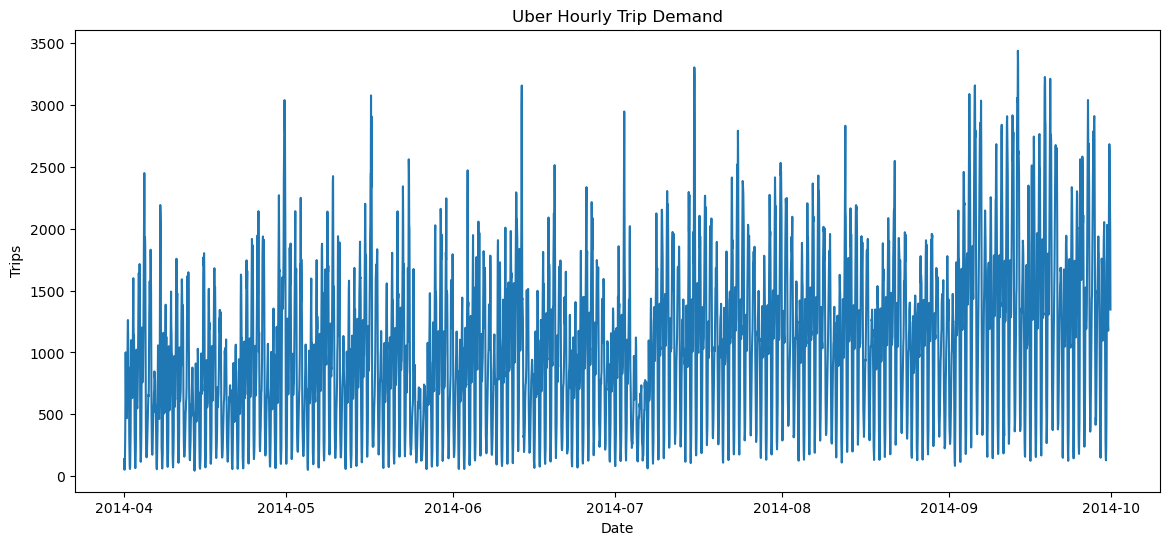

In [51]:
plt.figure(figsize=(14,6))

plt.plot(uber_hourly_trips["Trips"])

plt.title("Uber Hourly Trip Demand")
plt.xlabel("Date")
plt.ylabel("Trips")

plt.show()

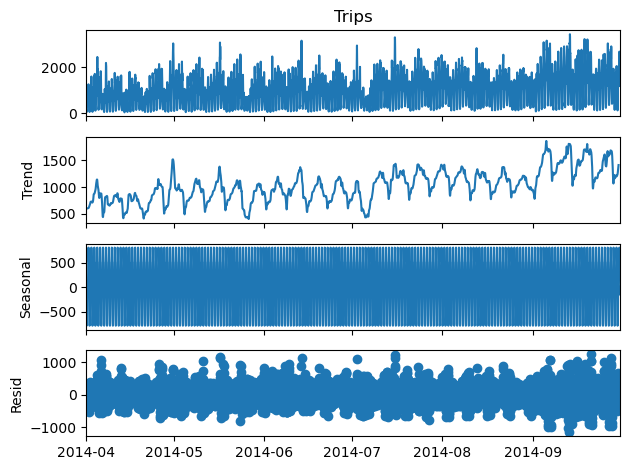

In [52]:
#Perform Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    uber_hourly_trips["Trips"],
    model="additive",
    period=24
)

result.plot()

plt.show()

#### Insight

The decomposition reveals strong daily seasonality, confirming that ride demand follows daily commuting patterns.

In [53]:
##Define Train-Test Split Point
cutoff_date = "2014-09-15"

In [54]:
train_data = uber_hourly_trips.loc[:cutoff_date]

In [55]:
test_data = uber_hourly_trips.loc[cutoff_date:]

In [56]:
print("Training dataset size:", train_data.shape)
print("Testing dataset size:", test_data.shape)

Training dataset size: (4032, 1)
Testing dataset size: (383, 1)


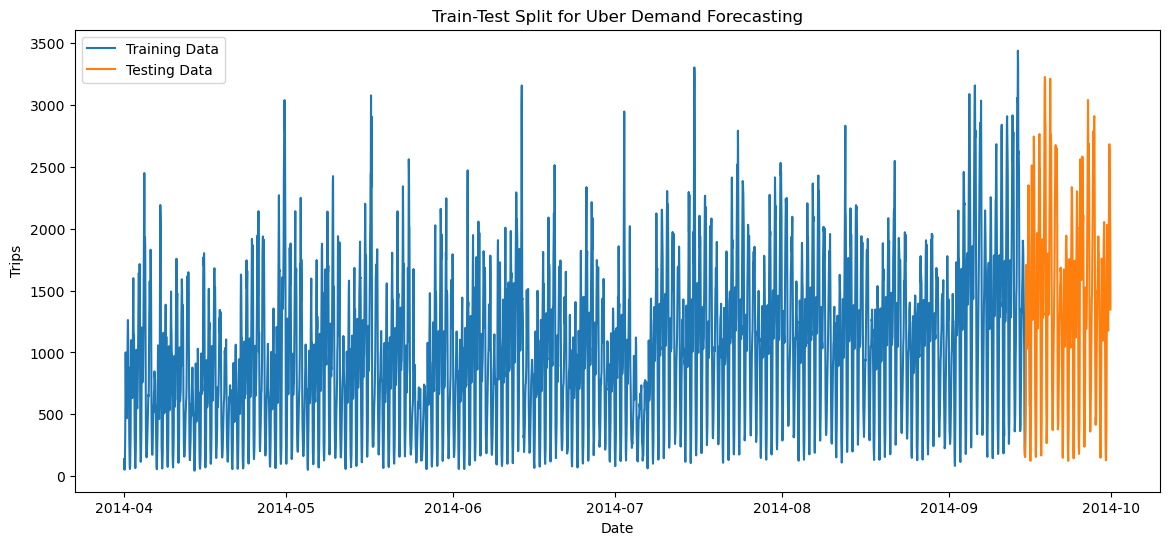

In [57]:
plt.figure(figsize=(14,6))

plt.plot(train_data, label="Training Data")
plt.plot(test_data, label="Testing Data")

plt.title("Train-Test Split for Uber Demand Forecasting")
plt.xlabel("Date")
plt.ylabel("Trips")

plt.legend()

plt.show()

### Step 8 — Feature Engineering 

#### Objective : To create meaningful predictor variables from the time-series dataset that allow machine learning models to capture temporal patterns, seasonality, and demand trends.

#### Purpose :
machine learning models cannot automatically understand time relationships.

Therefore we create engineered features that represent:

recent demand patterns

short-term trends

seasonal cycles

daily commuting patterns

These features significantly improve forecasting accuracy.


#### Step 8.1 – Lag Features
Objective

Provide models with previous demand observations.

Lag features are among the most important features in time-series forecasting.

In [58]:
# Create lag features

uber_hourly_trips["lag_1"] = uber_hourly_trips["Trips"].shift(1)
uber_hourly_trips["lag_2"] = uber_hourly_trips["Trips"].shift(2)
uber_hourly_trips["lag_3"] = uber_hourly_trips["Trips"].shift(3)

In [59]:
# Remove rows with missing values created by lag features

uber_hourly_trips = uber_hourly_trips.dropna()

In [60]:
# Display first rows after feature creation

uber_hourly_trips.head()

,Trips,lag_1,lag_2,lag_3
Date/Time,,,,
2014-04-01 03:00:00,93,53.0,66.0,138.0
2014-04-01 04:00:00,166,93.0,53.0,66.0
2014-04-01 05:00:00,333,166.0,93.0,53.0
2014-04-01 06:00:00,722,333.0,166.0,93.0
2014-04-01 07:00:00,1001,722.0,333.0,166.0


In [61]:
# Check dataset size after feature creation

uber_hourly_trips.shape

(4388, 4)

#### Step 8.2 – Create Rolling Window Features

#### Objective

Capture short-term demand trends and volatility.

Rolling statistics smooth short-term fluctuations.

In [62]:
# Create rolling mean feature (3-hour window)

uber_hourly_trips["rolling_mean_3"] = uber_hourly_trips["Trips"].rolling(window=3).mean()

In [63]:
# Create rolling standard deviation feature

uber_hourly_trips["rolling_std_3"] = uber_hourly_trips["Trips"].rolling(window=3).std()

In [64]:
# Remove rows with missing values caused by rolling calculations

uber_hourly_trips = uber_hourly_trips.dropna()

In [65]:
# Display dataset with new features

uber_hourly_trips.head()

,Trips,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3
Date/Time,,,,,,
2014-04-01 05:00:00,333,166.0,93.0,53.0,197.333333,123.029807
2014-04-01 06:00:00,722,333.0,166.0,93.0,407.000000,285.291079
2014-04-01 07:00:00,1001,722.0,333.0,166.0,685.333333,335.506085
2014-04-01 08:00:00,780,1001.0,722.0,333.0,834.333333,147.222055
2014-04-01 09:00:00,532,780.0,1001.0,722.0,771.000000,234.629495


#### Step 8.3 – Create Seasonal Lag Feature

#### Objective

Capture daily seasonality.

Ride demand often repeats similar patterns every 24 hours.

This feature is widely used in ride-sharing forecasting competitions.

In [66]:
# 24-hour seasonal lag feature

uber_hourly_trips["lag_24"] = uber_hourly_trips["Trips"].shift(24)

In [67]:
# Extract time components

uber_hourly_trips["Hour"] = uber_hourly_trips.index.hour
uber_hourly_trips["DayOfWeek"] = uber_hourly_trips.index.dayofweek
uber_hourly_trips["Month"] = uber_hourly_trips.index.month

In [68]:
uber_hourly_trips.head()

,Trips,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,lag_24,Hour,DayOfWeek,Month
Date/Time,,,,,,,,,,
2014-04-01 05:00:00,333,166.0,93.0,53.0,197.333333,123.029807,NaN,5,1,4
2014-04-01 06:00:00,722,333.0,166.0,93.0,407.000000,285.291079,NaN,6,1,4
2014-04-01 07:00:00,1001,722.0,333.0,166.0,685.333333,335.506085,NaN,7,1,4
2014-04-01 08:00:00,780,1001.0,722.0,333.0,834.333333,147.222055,NaN,8,1,4
2014-04-01 09:00:00,532,780.0,1001.0,722.0,771.000000,234.629495,NaN,9,1,4


#### Step 8.5 – Cyclical Time Encoding

#### Objective

Encode time variables so models understand cyclical patterns.

In [69]:
import numpy as np

# Cyclical encoding for Hour

uber_hourly_trips["Hour_sin"] = np.sin(
    2 * np.pi * uber_hourly_trips["Hour"] / 24
)

uber_hourly_trips["Hour_cos"] = np.cos(
    2 * np.pi * uber_hourly_trips["Hour"] / 24
)

In [70]:
# Remove rows with missing values

uber_hourly_trips = uber_hourly_trips.dropna()

In [71]:
uber_hourly_trips.head()

,Trips,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,lag_24,Hour,DayOfWeek,Month,Hour_sin,Hour_cos
Date/Time,,,,,,,,,,,,
2014-04-02 05:00:00,344,196.0,80.0,59.0,206.666667,132.322838,333.0,5,2,4,0.965926,2.588190e-01
2014-04-02 06:00:00,785,344.0,196.0,80.0,441.666667,306.405505,722.0,6,2,4,1.000000,6.123234e-17
2014-04-02 07:00:00,1099,785.0,344.0,196.0,742.666667,379.276065,1001.0,7,2,4,0.965926,-2.588190e-01
2014-04-02 08:00:00,927,1099.0,785.0,344.0,937.000000,157.238672,780.0,8,2,4,0.866025,-5.000000e-01
2014-04-02 09:00:00,656,927.0,1099.0,785.0,894.000000,223.336070,532.0,9,2,4,0.707107,-7.071068e-01


### Step 9 – Model Training

#### Objective

Train machine learning models capable of predicting future Uber trip demand using engineered time-series features.

#### Purpose

In previous steps we:

Converted raw trip data into hourly demand time series

Created advanced predictive features such as: lag features, rolling statistics, seasonal lag, cyclical time encoding

These features now allow machine learning algorithms to learn patterns in demand.

The goal of this step is to train three different forecasting models and evaluate their ability to capture demand patterns.

Using multiple models helps identify which algorithm performs best for this forecasting problem.

In [72]:
# Define feature variables

X = uber_hourly_trips.drop("Trips", axis=1)

# Define target variable

y = uber_hourly_trips["Trips"]

In [73]:
print(X.shape)
print(y.shape)

(4362, 11)
(4362,)


In [74]:
# Training features

X_train = train_data.join(X).drop("Trips", axis=1)

# Training target

y_train = train_data["Trips"]

# Testing features

X_test = test_data.join(X).drop("Trips", axis=1)

# Testing target

y_test = test_data["Trips"]

#### Step 9.1 – Train Random Forest Model
#### Objective

Train a Random Forest Regressor to predict trip demand.

Random Forest is powerful because it can capture nonlinear relationships and feature interactions.

In [75]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=200, random_state=42)

#### Step 9.2 – Train Gradient Boosted Regression Trees
#### Objective

Train a Gradient Boosting Regressor, which builds models sequentially to reduce prediction errors.

In [77]:
X_train.isna().sum()

lag_1             29
lag_2             29
lag_3             29
rolling_mean_3    29
rolling_std_3     29
lag_24            29
Hour              29
DayOfWeek         29
Month             29
Hour_sin          29
Hour_cos          29
dtype: int64

In [79]:
# Remove rows with NaN values

X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

In [80]:
X_train.isna().sum()

lag_1             0
lag_2             0
lag_3             0
rolling_mean_3    0
rolling_std_3     0
lag_24            0
Hour              0
DayOfWeek         0
Month             0
Hour_sin          0
Hour_cos          0
dtype: int64

In [81]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5
)

gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=5, n_estimators=200)

#### Step 9.3 – Train XGBoost Model
#### Objective

Train XGBoost, one of the most powerful algorithms for tabular machine learning problems.

In [82]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

#### Step 9.4 – Generate Predictions

In [83]:
rf_pred = rf_model.predict(X_test)

gbr_pred = gbr_model.predict(X_test)

xgb_pred = xgb_model.predict(X_test)

In [84]:
print(rf_pred[:5])

[291.905 172.235 152.675 341.515 550.16 ]


### Step 10 – Model Evaluation
#### Objective

Evaluate the forecasting performance of trained machine learning models by comparing predicted Uber trip demand with actual observed demand.

#### Purpose

After training our forecasting models , we must evaluate how accurately they predict future demand.

Model evaluation allows us to:

measure forecasting accuracy

compare multiple models objectively

identify the best-performing model

In demand forecasting, one of the most widely used metrics is:

MAPE – Mean Absolute Percentage Error

MAPE measures the average percentage difference between predicted and actual values, making it easy to interpret.

< 10% : Excellent forecasting, 10–20% : Good forecasting, > 20%	Poor : forecasting
 

In [85]:
from sklearn.metrics import mean_absolute_percentage_error

In [86]:
# Calculate MAPE for each model

rf_mape = mean_absolute_percentage_error(y_test, rf_pred)

gbr_mape = mean_absolute_percentage_error(y_test, gbr_pred)

xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)

print("Random Forest MAPE:", rf_mape)
print("Gradient Boosting MAPE:", gbr_mape)
print("XGBoost MAPE:", xgb_mape)

Random Forest MAPE: 0.04050289702390489
Gradient Boosting MAPE: 0.03154887290741132
XGBoost MAPE: 0.03207654505968094


In [87]:
import pandas as pd

model_results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "MAPE": [rf_mape, gbr_mape, xgb_mape]
})

model_results

,Model,MAPE
0,Random Forest,0.040503
1,Gradient Boosting,0.031549
2,XGBoost,0.032077


#### Insight

The table presents the forecasting accuracy of the three machine learning models evaluated using Mean Absolute Percentage Error (MAPE).

The results indicate that Gradient Boosting achieved the lowest forecasting error (3.15%), making it the most accurate model among the three. XGBoost follows closely with 3.21% error, while Random Forest shows slightly higher error at 4.05%.

Overall, all models demonstrate very strong predictive capability, with error rates well below 10%, indicating high reliability for Uber demand forecasting.

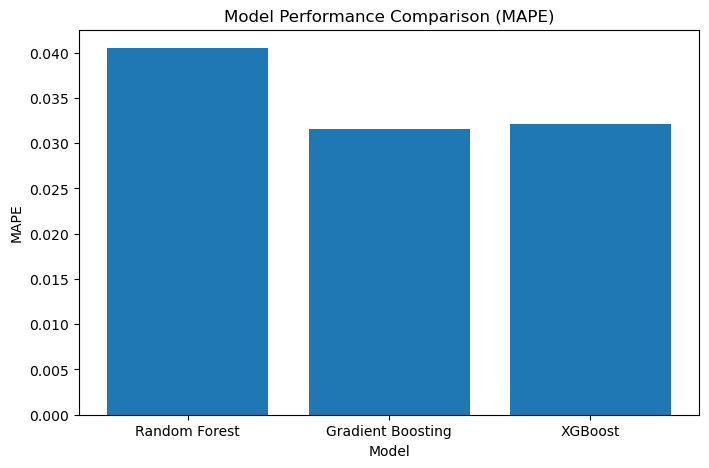

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    model_results["Model"],
    model_results["MAPE"]
)

plt.title("Model Performance Comparison (MAPE)")
plt.xlabel("Model")
plt.ylabel("MAPE")

plt.show()

#### Step 10.1 – Actual vs Predicted Demand Visualization

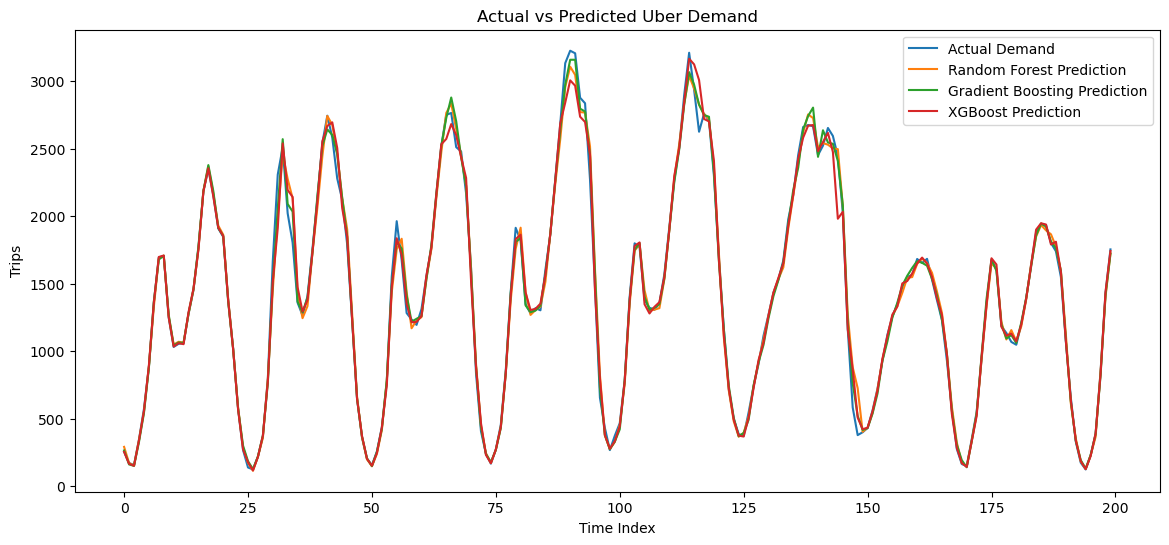

In [90]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values[:200], label="Actual Demand")

plt.plot(rf_pred[:200], label="Random Forest Prediction")

plt.plot(gbr_pred[:200], label="Gradient Boosting Prediction")

plt.plot(xgb_pred[:200], label="XGBoost Prediction")

plt.title("Actual vs Predicted Uber Demand")

plt.xlabel("Time Index")

plt.ylabel("Trips")

plt.legend()

plt.show()

#### Step 10.2 – Residual Error Analysis

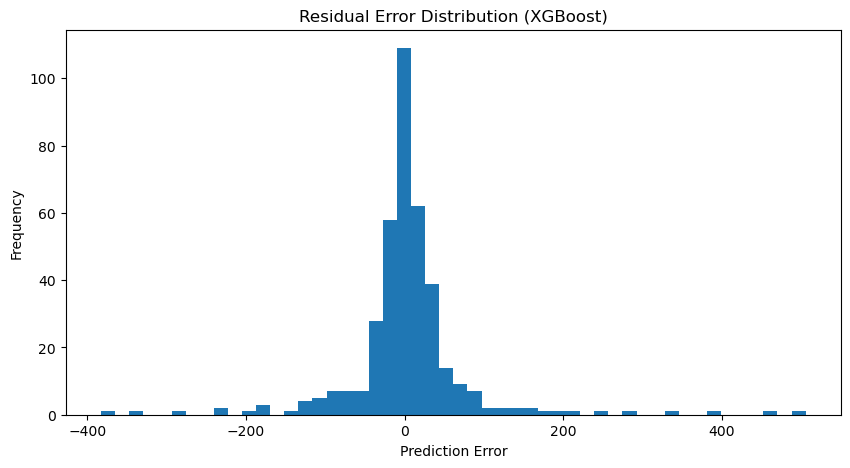

In [91]:
# Calculate residual errors

residuals = y_test - xgb_pred

plt.figure(figsize=(10,5))

plt.hist(residuals, bins=50)

plt.title("Residual Error Distribution (XGBoost)")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

#### Overall Evaluation Insight 

The model evaluation results demonstrate that machine learning techniques are highly effective for forecasting Uber trip demand. Among the tested models, Gradient Boosting achieved the best performance with the lowest MAPE, followed closely by XGBoost. The prediction visualizations further confirm that the models successfully capture key temporal demand patterns such as daily cycles and peak demand periods.

These findings indicate that boosting-based ensemble models provide strong predictive accuracy for ride demand forecasting, making them suitable for operational planning and ride allocation strategies.